# **Universidad de Buenos Aires**
## **Facultad de Ciencias Económicas**
### **Métodos Predictivos**
### Cátedra: Bianco
#### **Transformación de Variables para Regresión Lineal**

In [1]:
from scipy import stats
from scipy.stats import chi2_contingency
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import MultiComparison
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [2]:
# Dataset Wage del libro ISLR
url = "https://raw.githubusercontent.com/JWarmenhoven/ISLR-python/master/Notebooks/Data/Wage.csv"
df = pd.read_csv(url, index_col=0)
df.head()

,year,age,sex,maritl,race,education,region,jobclass,health,health_ins,logwage,wage
231655,2006,18,1. Male,1. Never Married,1. White,1. < HS Grad,2. Middle Atlantic,1. Industrial,1. <=Good,2. No,4.318063,75.043154
86582,2004,24,1. Male,1. Never Married,1. White,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,2. No,4.255273,70.476020
161300,2003,45,1. Male,2. Married,1. White,3. Some College,2. Middle Atlantic,1. Industrial,1. <=Good,1. Yes,4.875061,130.982177
155159,2003,43,1. Male,2. Married,3. Asian,4. College Grad,2. Middle Atlantic,2. Information,2. >=Very Good,1. Yes,5.041393,154.685293
11443,2005,50,1. Male,4. Divorced,1. White,2. HS Grad,2. Middle Atlantic,2. Information,1. <=Good,1. Yes,4.318063,75.043154


In [3]:
# Borramos columnas sin clasificación útil
df.drop(columns=['sex', 'region'], inplace=True)

# Variable dependiente transformada
df['log_wage'] = np.log(df['wage'])

# Término cuadrático (variable independiente)
df['age2'] = df['age'] ** 2

---

# Transformación de Variables Continuas

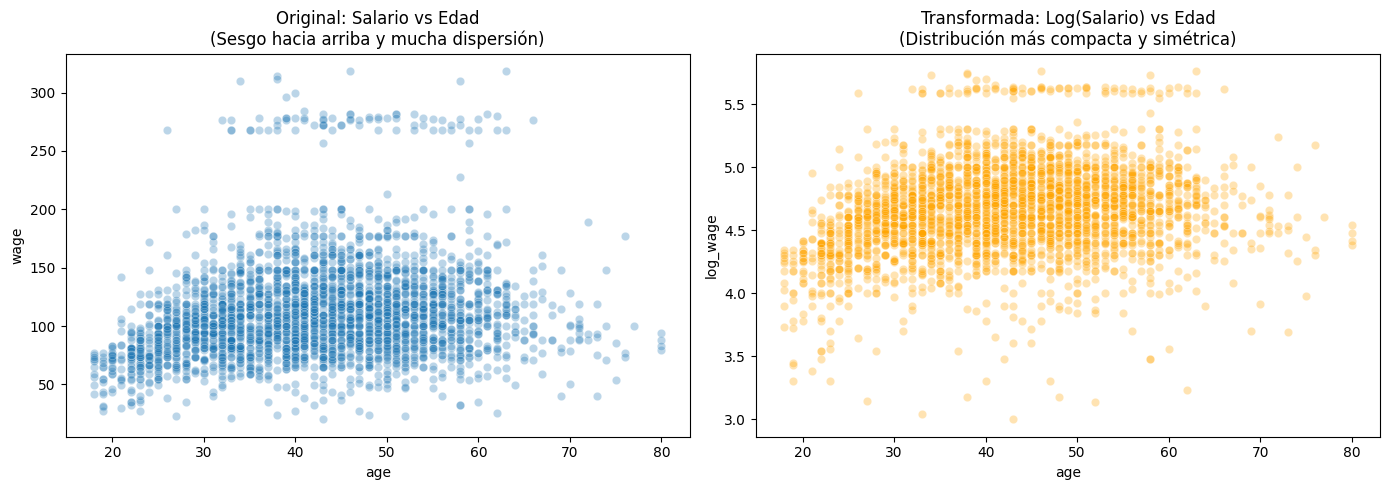

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Antes: salario en niveles
sns.scatterplot(data=df, x='age', y='wage', alpha=0.3, ax=ax[0])
ax[0].set_title('Original: Salario vs Edad\n(Sesgo hacia arriba y mucha dispersión)')

# Después: salario en logaritmo
sns.scatterplot(data=df, x='age', y='log_wage', alpha=0.3, ax=ax[1], color='orange')
ax[1].set_title('Transformada: Log(Salario) vs Edad\n(Distribución más compacta y simétrica)')

plt.tight_layout()
plt.show()

Usando la función `regplot`, se puede graficar la tendencia entre los puntos.

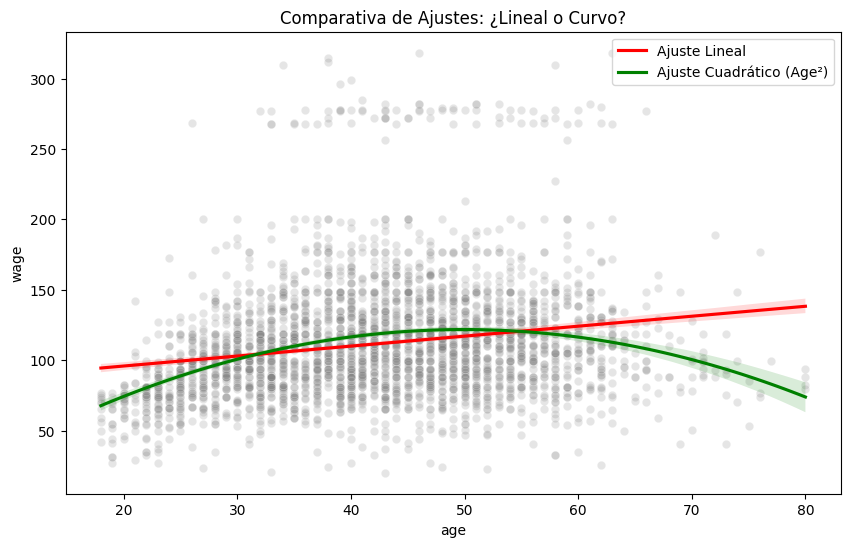

In [5]:
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x='age', y='wage', alpha=0.2, color='gray')

# Tendencia lineal
sns.regplot(data=df, x='age', y='wage', scatter=False, order=1,
            label='Ajuste Lineal', color='red')

# Tendencia cuadrática (capta el pico de productividad ~45-50 años)
sns.regplot(data=df, x='age', y='wage', scatter=False, order=2,
            label='Ajuste Cuadrático (Age²)', color='green')

plt.title('Comparativa de Ajustes: ¿Lineal o Curvo?')
plt.legend()
plt.show()

## Punto máximo de la parábola

Cuando se incluye una función de parábola, es importante obtener el punto máximo (o mínimo), que resulta crítico para saber cuándo comenzará a disminuir y cuándo a incrementarse, dependiendo del signo.

Para un modelo con la forma:
$$y = \beta_0 + \beta_1 \cdot Age + \beta_2 \cdot Age^2$$

La derivada respecto a la edad es:
$$\frac{dy}{dAge} = \beta_1 + 2\beta_2 \cdot Age$$

Igualamos a cero para encontrar el máximo:
$$0 = \beta_1 + 2\beta_2 \cdot Age \implies Age_{max} = -\frac{\beta_1}{2\beta_2}$$

## Comparación de modelos

### Modelo 1 — Lineal simple
$$Wage = \beta_0 + \beta_1 \cdot Age$$

In [6]:
modelo_age_wage = smf.ols("wage ~ age", data=df).fit()
print(modelo_age_wage.summary())

                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.038
Model:                            OLS   Adj. R-squared:                  0.038
Method:                 Least Squares   F-statistic:                     119.3
Date:                dom, 31 may 2026   Prob (F-statistic):           2.90e-27
Time:                        00:14:25   Log-Likelihood:                -15391.
No. Observations:                3000   AIC:                         3.079e+04
Df Residuals:                    2998   BIC:                         3.080e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     81.7047      2.846     28.706      0.0

### Modelo 2 — Cuadrático puro
$$Wage = \beta_0 + \beta_2 \cdot Age^2$$

> Generalmente es un mal modelo, útil solo para comparar.

In [7]:
modelo_age2_wage = smf.ols("wage ~ age2", data=df).fit()
print(modelo_age2_wage.summary())

                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.025
Model:                            OLS   Adj. R-squared:                  0.025
Method:                 Least Squares   F-statistic:                     77.71
Date:                dom, 31 may 2026   Prob (F-statistic):           1.98e-18
Time:                        00:14:32   Log-Likelihood:                -15411.
No. Observations:                3000   AIC:                         3.083e+04
Df Residuals:                    2998   BIC:                         3.084e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     99.0432      1.621     61.091      0.0

### Modelo 3 — Polinómico (Lineal + Cuadrático)
$$Wage = \beta_0 + \beta_1 \cdot Age + \beta_2 \cdot Age^2$$

El estándar para capturar curvas.

In [8]:
modelo_ages_wage = smf.ols("wage ~ age + age2", data=df).fit()
print(modelo_ages_wage.summary())

# Cálculo del pico salarial
beta1_m3 = modelo_ages_wage.params['age']
beta2_m3 = modelo_ages_wage.params['age2']
pico_m3  = -beta1_m3 / (2 * beta2_m3)
print(f"\nPico salarial Modelo 3: {pico_m3:.2f} años")

                            OLS Regression Results                            
Dep. Variable:                   wage   R-squared:                       0.082
Model:                            OLS   Adj. R-squared:                  0.081
Method:                 Least Squares   F-statistic:                     134.0
Date:                dom, 31 may 2026   Prob (F-statistic):           1.82e-56
Time:                        00:14:36   Log-Likelihood:                -15321.
No. Observations:                3000   AIC:                         3.065e+04
Df Residuals:                    2997   BIC:                         3.067e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -10.4252      8.190     -1.273      0.2

**Interpretación Modelo 3 (niveles):**

Si $\beta_1 \approx \$5.3$ y $\beta_2 \approx -\$0.05$:

Por cada año de edad, el salario sube \$5.3, pero según el factor de rendimientos decrecientes ese incremento se reduce \$0.05 por año.
El salario alcanzará su pico máximo alrededor de los **49-50 años**, para luego decrecer.

### Modelo 4 — Log-Polinómico (Log-Nivel con curvatura)
$$\ln(Wage) = \beta_0 + \beta_1 \cdot Age + \beta_2 \cdot Age^2$$

In [9]:
modelo_ages_logwage = smf.ols("log_wage ~ age + age2", data=df).fit()
print(modelo_ages_logwage.summary())

# Cálculo del pico salarial
beta1_m4 = modelo_ages_logwage.params['age']
beta2_m4 = modelo_ages_logwage.params['age2']
pico_m4  = -beta1_m4 / (2 * beta2_m4)
print(f"\nPico salarial Modelo 4: {pico_m4:.2f} años")

                            OLS Regression Results                            
Dep. Variable:               log_wage   R-squared:                       0.107
Model:                            OLS   Adj. R-squared:                  0.106
Method:                 Least Squares   F-statistic:                     179.3
Date:                dom, 31 may 2026   Prob (F-statistic):           2.81e-74
Time:                        00:14:42   Log-Likelihood:                -952.31
No. Observations:                3000   AIC:                             1911.
Df Residuals:                    2997   BIC:                             1929.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.4681      0.068     50.928      0.0

**Interpretación Modelo 4 (log-niveles):**

Si $\beta_1 \approx 5.17\%$ y $\beta_2 \approx -0.005\%$:

Por cada año de edad, el salario sube un 5.17%. Pero esa tasa se reduce 0.005% año a año.

---

### Semi-elasticidad en el modelo log-cuadrático

En un modelo log-cuadrático, la tasa de crecimiento del salario no es fija. Depende de la edad actual:

$$\% \Delta Wage \approx (\beta_1 + 2 \cdot \beta_2 \cdot Age) \times 100$$

Usando $\beta_1 = 0.0517$ y $\beta_2 = -0.0005$:

| Edad | Crecimiento salarial |
|---|---|
| 20 años | $(0.0517 + 2 \cdot (-0.0005) \cdot 20) \times 100 = 3.17\%$ |
| 40 años | $(0.0517 + 2 \cdot (-0.0005) \cdot 40) \times 100 = 1.17\%$ |
| ~50 años | $\approx 0\%$ — punto donde la curva se aplana |
| 60 años | $(0.0517 + 2 \cdot (-0.0005) \cdot 60) \times 100 = -0.83\%$ |

---

### ¿Por qué mejora el $R^2$ al aplicar el logaritmo?

La lógica de la relación (sube y baja) es la misma. Pero el Modelo 3 habla de **dólares** y el Modelo 4 habla de **porcentajes**. En economía, se prefieren los porcentajes porque el crecimiento del bienestar suele ser relativo, no absoluto.

En el Modelo 3, OLS intentaba explicar variaciones de miles de dólares. Los salarios muy altos (outliers) tienen mucha "fuerza" y si el modelo no los alcanza, el error se penaliza al cuadrado ($e^2$), bajando el $R^2$. Al tomar logaritmo, esas distancias extremas se comprimen.

---

# Análisis entre Variables Cualitativas — Chi-Cuadrado

La prueba Chi-Cuadrado permite evaluar si existe asociación entre dos variables categóricas.

In [10]:
# Tabla de contingencia (frecuencias cruzadas)
tabla_cruzada = pd.crosstab(df['maritl'], df['health'])
tabla_cruzada

health,1. <=Good,2. >=Very Good
maritl,,
1. Never Married,186,462
2. Married,568,1506
3. Widowed,7,12
4. Divorced,79,125
5. Separated,18,37


In [11]:
# Prueba Chi-cuadrado
stat, p, dof, expected = chi2_contingency(tabla_cruzada)

print("--- PRUEBA DE ASOCIACIÓN CHI-CUADRADO ---")
print(f"Estadístico Chi²: {stat:.4f}")
print(f"P-valor          : {p:.4f}")
print(f"Grados de libertad: {dof}")

--- PRUEBA DE ASOCIACIÓN CHI-CUADRADO ---
Estadístico Chi²: 12.8318
P-valor          : 0.0121
Grados de libertad: 4


Con un **p-valor < 0.05** existe una asociación significativa entre el Estado Civil y la Salud: la salud no se distribuye de la misma forma en todos los estados civiles.

---

# Análisis entre Variables Cualitativas y Continuas

## ANOVA — Análisis de la Varianza

Permite comparar las medias de una variable continua entre los grupos definidos por una variable categórica.

### Variable: `race`

In [12]:
factor     = 'race'
dependiente = 'log_wage'

formula = f'{dependiente} ~ {factor}'
modelo  = ols(formula, data=df).fit()
tabla_anova = anova_lm(modelo)

print(f"--- RESULTADO ANOVA PARA {factor.upper()} ---")
print(tabla_anova)

--- RESULTADO ANOVA PARA RACE ---
              df      sum_sq   mean_sq          F        PR(>F)
race         3.0    4.538825  1.512942  12.366816  4.881332e-08
Residual  2996.0  366.527099  0.122339        NaN           NaN


### Ajuste Tukey (HSD)

Compara todos los pares de grupos para identificar cuáles difieren significativamente.

**Interpretación:** La columna `meandiff` representa $\text{Media del Grupo 2} - \text{Media del Grupo 1}$.
- Signo **+**: el Grupo 2 tiene mayor media.
- Signo **-**: el Grupo 2 tiene menor media.

In [13]:
mc = MultiComparison(df[dependiente], df[factor])
result_tukey = mc.tukeyhsd()
print(result_tukey)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1   group2  meandiff p-adj   lower   upper  reject
--------------------------------------------------------
1. White 2. Black  -0.0909 0.0002 -0.1464 -0.0354   True
1. White 3. Asian   0.0587 0.1157  -0.009  0.1264  False
1. White 4. Other  -0.2108 0.0016 -0.3597 -0.0619   True
2. Black 3. Asian   0.1496    0.0  0.0658  0.2333   True
2. Black 4. Other  -0.1199 0.2016 -0.2768  0.0369  False
3. Asian 4. Other  -0.2695 0.0001 -0.4311 -0.1079   True
--------------------------------------------------------


In [14]:
medias = df.groupby(factor)[dependiente].mean().sort_values(ascending=False)
print(medias)

race
3. Asian    4.720350
1. White    4.661666
2. Black    4.570769
4. Other    4.450853
Name: log_wage, dtype: float64


### Ajuste de Bonferroni

In [15]:
# Bonferroni (method='b')
print(mc.allpairtest(stats.ttest_ind, method='b')[0])

Test Multiple Comparison ttest_ind 
FWER=0.05 method=b
alphacSidak=0.01, alphacBonf=0.008
 group1   group2    stat   pval  pval_corr reject
-------------------------------------------------
1. White 2. Black  4.2234    0.0    0.0001   True
1. White 3. Asian -2.1998 0.0279    0.1674  False
1. White 4. Other  3.6135 0.0003    0.0018   True
2. Black 3. Asian -4.7722    0.0       0.0   True
2. Black 4. Other  2.2196 0.0271    0.1628  False
3. Asian 4. Other  4.0949 0.0001    0.0004   True
-------------------------------------------------


---

### Variable: `maritl` (Estado Civil)

In [16]:
factor     = 'maritl'
dependiente = 'log_wage'

formula = f'{dependiente} ~ {factor}'
modelo  = ols(formula, data=df).fit()
tabla_anova = anova_lm(modelo)

print(f"--- RESULTADO ANOVA PARA {factor.upper()} ---")
print(tabla_anova)

--- RESULTADO ANOVA PARA MARITL ---
              df      sum_sq   mean_sq          F        PR(>F)
maritl       4.0   31.157363  7.789341  68.633385  1.160603e-55
Residual  2995.0  339.908561  0.113492        NaN           NaN


In [17]:
mc = MultiComparison(df[dependiente], df[factor])
result_tukey = mc.tukeyhsd()
print(result_tukey)

        Multiple Comparison of Means - Tukey HSD, FWER=0.05         
     group1         group2    meandiff p-adj   lower   upper  reject
--------------------------------------------------------------------
1. Never Married   2. Married   0.2447    0.0  0.2033   0.286   True
1. Never Married   3. Widowed   0.0959 0.7382 -0.1182  0.3099  False
1. Never Married  4. Divorced   0.1092 0.0005  0.0354   0.183   True
1. Never Married 5. Separated   0.1017 0.1994 -0.0274  0.2309  False
      2. Married   3. Widowed  -0.1488 0.3087 -0.3607  0.0631  False
      2. Married  4. Divorced  -0.1355    0.0 -0.2029  -0.068   True
      2. Married 5. Separated  -0.1429 0.0164 -0.2686 -0.0173   True
      3. Widowed  4. Divorced   0.0133 0.9998 -0.2072  0.2339  False
      3. Widowed 5. Separated   0.0059    1.0 -0.2388  0.2505  False
     4. Divorced 5. Separated  -0.0075 0.9999 -0.1472  0.1322  False
--------------------------------------------------------------------


In [18]:
medias = df.groupby(factor)[dependiente].mean().sort_values(ascending=False)
print(medias)

maritl
2. Married          4.719525
4. Divorced         4.584067
5. Separated        4.576588
3. Widowed          4.570733
1. Never Married    4.474867
Name: log_wage, dtype: float64


In [19]:
print(mc.allpairtest(stats.ttest_ind, method='b')[0])

Test Multiple Comparison ttest_ind 
FWER=0.05 method=b
alphacSidak=0.01, alphacBonf=0.005
     group1         group2      stat    pval  pval_corr reject
--------------------------------------------------------------
1. Never Married   2. Married -16.0474    0.0       0.0   True
1. Never Married   3. Widowed  -1.2507 0.2115       1.0  False
1. Never Married  4. Divorced  -4.1027    0.0    0.0004   True
1. Never Married 5. Separated   -2.215 0.0271    0.2708  False
      2. Married   3. Widowed    1.896 0.0581    0.5809  False
      2. Married  4. Divorced   5.4229    0.0       0.0   True
      2. Married 5. Separated   3.0811 0.0021    0.0209   True
      3. Widowed  4. Divorced  -0.1697 0.8654       1.0  False
      3. Widowed 5. Separated  -0.0816 0.9352       1.0  False
     4. Divorced 5. Separated   0.1532 0.8784       1.0  False
--------------------------------------------------------------


---

# Ajuste con Variables Cualitativas y Continuas — Modelo Completo

Incluimos todas las variables: continuas (con curvatura) y categóricas (con `C()` para generar dummies automáticamente).

$$\ln(wage) = \beta_0 + \beta_1 \cdot age + \beta_2 \cdot age^2 + \sum_j \gamma_j D_j + \varepsilon$$

In [20]:
formula = 'log_wage ~ age + age2 + C(education) + C(jobclass) + C(health) + C(maritl) + C(race) + C(health_ins)'
modelo_multiple = smf.ols(formula, data=df).fit()
print(modelo_multiple.summary())

                            OLS Regression Results                            
Dep. Variable:               log_wage   R-squared:                       0.385
Model:                            OLS   Adj. R-squared:                  0.381
Method:                 Least Squares   F-statistic:                     116.5
Date:                dom, 31 may 2026   Prob (F-statistic):          1.55e-299
Time:                        00:15:39   Log-Likelihood:                -393.71
No. Observations:                3000   AIC:                             821.4
Df Residuals:                    2983   BIC:                             923.5
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Inte